In [15]:
!pip install jupyter ipykernel pandas matplotlib seaborn

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

root_path = Path(os.getcwd()).parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path / "src"))

from utils import pump_sensors
from data import load_all_datasets
from evaluation import evaluate_zscore_experiment

In [17]:
data_path = "../../data/processed/data_11-03_10-04/"

train_dict, test_severe_dict, test_small_dict = load_all_datasets(data_path)

print(train_dict.keys())
print(test_severe_dict.keys())
print(test_small_dict.keys())

dict_keys([1, 2, 3, 5, 8, 12, 13, 14, 15])
dict_keys(['16_F1', '16_F2', '16_F3', '16_F4', '17_F1', '17_F2', '17_F3', '17_F4'])
dict_keys(['16_F1', '16_F2', '16_F3', '16_F4', '17_F1', '17_F2', '17_F3', '17_F4'])


In [18]:
test_sets = {
    "severe": test_severe_dict,
    "small": test_small_dict
}
all_results = []

for train_id, train_df in train_dict.items():
    for severity, test_dict in test_sets.items():
        for test_id, test_df in test_dict.items():

            metrics, _ = evaluate_zscore_experiment(
                train_df=train_df,
                test_df=test_df,
                sensors=pump_sensors,
                threshold=3
            )
            all_results.append({
                "train_session": train_id,
                "test_session": test_id,
                "severity": severity,
                **metrics
            })

results_table = pd.DataFrame(all_results)

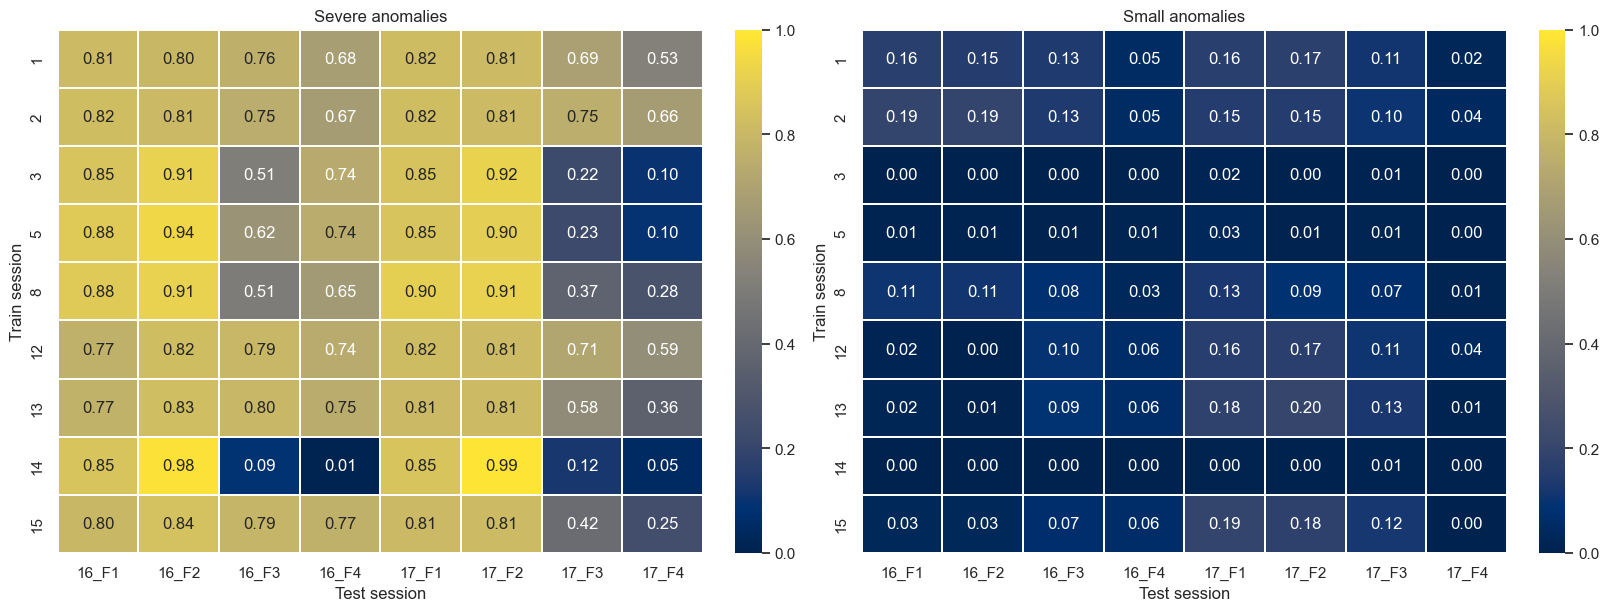

In [19]:
pivot_severe = results_table[
    results_table["severity"] == "severe"
].pivot(index="train_session", columns="test_session", values="f1")

pivot_small = results_table[
    results_table["severity"] == "small"
].pivot(index="train_session", columns="test_session", values="f1")

vmin = 0
vmax = 1

fig, ax = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
sns.set_theme(style="white", font_scale=1.0)
sns.heatmap(
    pivot_severe,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=vmin,
    vmax=vmax,
    linewidths=0.3,
    linecolor="white",
    cbar=True,
    ax=ax[0]
)

ax[0].set_title("Severe anomalies", fontsize=12)
ax[0].set_xlabel("Test session")
ax[0].set_ylabel("Train session")

sns.heatmap(
    pivot_small,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=vmin,
    vmax=vmax,
    linewidths=0.3,
    linecolor="white",
    cbar=True,
    ax=ax[1]
)

ax[1].set_title("Small anomalies", fontsize=12)
ax[1].set_xlabel("Test session")
ax[1].set_ylabel("Train session")

plt.show()